In [1]:
import fastf1
import pandas as pd
from pathlib import Path

# FastF1 usa una caché para no descargar los mismos datos dos veces
# Creamos una carpeta para guardarla
CACHE_PATH = Path("../data/raw/cache")
CACHE_PATH.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_PATH))

print("✅ FastF1 listo")
print(f"Versión: {fastf1.__version__}")

/Users/tomas/Data/f1-data/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ FastF1 listo
Versión: 3.7.0


In [2]:
# Cargar la sesión de clasificación del GP de Bahréin 2023
# Session types: 'FP1', 'FP2', 'FP3', 'Q' (qualifying), 'R' (race)
session = fastf1.get_session(2023, 'Bahrain', 'Q')
session.load()

print(f"✅ Sesión cargada: {session.event['EventName']} {session.event.year}")
print(f"Tipo: {session.name}")
print(f"Fecha: {session.date}")

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

✅ Sesión cargada: Bahrain Grand Prix 2023
Tipo: Qualifying
Fecha: 2023-03-04 15:00:00


In [3]:
# Ver los tiempos de vuelta de todos los pilotos
laps = session.laps

print(f"Total de vueltas: {len(laps):,}")
print(f"\nColumnas disponibles:")
print(laps.columns.tolist())

Total de vueltas: 254

Columnas disponibles:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [4]:
# Ver las primeras filas
laps[['Driver', 'LapTime', 'Sector1Time', 'Sector2Time', 
      'Sector3Time', 'Compound', 'IsPersonalBest']].head(10)

,Driver,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,IsPersonalBest
0,VER,NaT,NaT,NaT,NaT,SOFT,False
1,VER,NaT,NaT,0 days 00:00:53.666000,0 days 00:00:38.509000,SOFT,False
2,VER,0 days 00:01:31.295000,0 days 00:00:29.152000,0 days 00:00:39.195000,0 days 00:00:22.948000,SOFT,True
3,VER,0 days 00:01:49.812000,0 days 00:00:35.615000,0 days 00:00:44.953000,0 days 00:00:29.244000,SOFT,False
4,VER,NaT,NaT,0 days 00:00:53.390000,0 days 00:00:45.107000,SOFT,False
5,VER,0 days 00:02:12.516000,0 days 00:00:48.978000,0 days 00:00:48.136000,0 days 00:00:35.402000,SOFT,False
6,VER,NaT,NaT,0 days 00:00:56.693000,0 days 00:00:30.799000,SOFT,False
7,VER,0 days 00:01:30.503000,0 days 00:00:28.925000,0 days 00:00:38.915000,0 days 00:00:22.663000,SOFT,True
8,VER,0 days 00:02:05.756000,0 days 00:00:38.904000,0 days 00:00:53.517000,0 days 00:00:33.335000,SOFT,False
9,VER,NaT,NaT,0 days 00:00:52.962000,0 days 00:00:27.476000,SOFT,False


In [5]:
# ¿Quién hizo la vuelta más rápida?
fastest = laps.pick_fastest()
print(f"Vuelta más rápida: {fastest['Driver']} - {fastest['LapTime']}")
print(f"Compuesto: {fastest['Compound']}")
print(f"Sectores: {fastest['Sector1Time']} | {fastest['Sector2Time']} | {fastest['Sector3Time']}")

Vuelta más rápida: VER - 0 days 00:01:29.708000
Compuesto: SOFT
Sectores: 0 days 00:00:28.736000 | 0 days 00:00:38.514000 | 0 days 00:00:22.458000


In [6]:
# Mejor vuelta de cada piloto en clasificación
# pick_quicklaps() filtra vueltas limpias automáticamente
best_laps = laps.pick_quicklaps()

# Mejor vuelta por piloto
best_per_driver = best_laps.groupby('Driver')['LapTime'].min().sort_values()

# Convertir a segundos para poder trabajar numéricamente
best_per_driver_seconds = best_per_driver.dt.total_seconds()

print(best_per_driver_seconds)

Driver
VER    89.708
PER    89.846
LEC    90.000
SAI    90.154
ALO    90.336
RUS    90.340
HAM    90.384
HUL    90.809
STR    90.836
OCO    90.914
NOR    91.381
TSU    91.400
BOT    91.443
ALB    91.461
ZHO    91.473
SAR    91.652
GAS    91.818
MAG    91.892
PIA    92.101
DEV    92.121
Name: LapTime, dtype: float64


Matplotlib is building the font cache; this may take a moment.


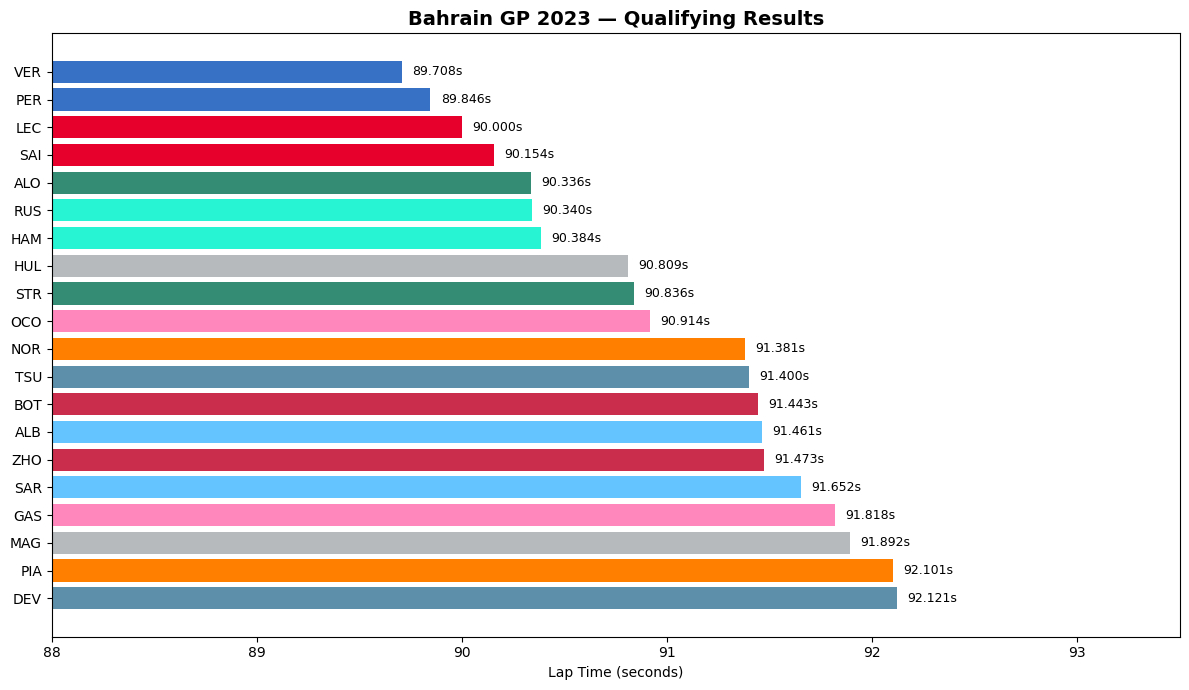

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colores por equipo (simplificado)
team_colors = {
    'VER': '#3671C6', 'PER': '#3671C6',  # Red Bull
    'LEC': '#E8002D', 'SAI': '#E8002D',  # Ferrari
    'HAM': '#27F4D2', 'RUS': '#27F4D2',  # Mercedes
    'ALO': '#358C75', 'STR': '#358C75',  # Aston Martin
    'NOR': '#FF8000', 'PIA': '#FF8000',  # McLaren
    'OCO': '#FF87BC', 'GAS': '#FF87BC',  # Alpine
    'BOT': '#C92D4B', 'ZHO': '#C92D4B',  # Alfa Romeo
    'TSU': '#5E8FAA', 'DEV': '#5E8FAA',  # AlphaTauri
    'HUL': '#B6BABD', 'MAG': '#B6BABD',  # Haas
    'ALB': '#64C4FF', 'SAR': '#64C4FF',  # Williams
}

fig, ax = plt.subplots(figsize=(12, 7))

drivers = best_per_driver_seconds.index.tolist()
times = best_per_driver_seconds.values
colors = [team_colors.get(d, '#888888') for d in drivers]

bars = ax.barh(drivers, times, color=colors)

# Añadir el tiempo como etiqueta
for bar, time in zip(bars, times):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{time:.3f}s", va='center', fontsize=9)

ax.set_xlabel("Lap Time (seconds)")
ax.set_title("Bahrain GP 2023 — Qualifying Results", fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(88, 93.5)

plt.tight_layout()
plt.show()

In [8]:
# Qué datos tiene una sesión de FastF1
print("Vueltas:", session.laps.columns.tolist())
print("\nResultados:", session.results.columns.tolist())
print("\nClima:", session.weather_data.columns.tolist())

Vueltas: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']

Resultados: ['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName', 'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition', 'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps']

Clima: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
